In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path
import joblib
import json
from collections import Counter

RAW_DIR  = Path("../data/raw")
BASE_DIR = Path("../data/processed")

RUL_CAP  = 125
SEQ_LEN  = 30
STRIDE   = 1

COLUMNS = (
    ["engine_id", "cycle"]
    + [f"op{i}" for i in range(1, 4)]
    + [f"s{i}"  for i in range(1, 22)]
)

DROP_COLS = ["s1","s5","s6","s10","s16","s18","s19","op3"]

FEATURE_COLS = [
    "op1","op2",
    "s2","s3","s4","s7","s8","s9",
    "s11","s12","s13","s14","s15","s17","s20","s21",
]

GLOBAL_SCALE = ["s3"]
PER_ENGINE   = [f for f in FEATURE_COLS if f not in GLOBAL_SCALE]

SUBSETS = ["FD002", "FD003", "FD004"]

print(f"FEATURE_COLS ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Global scaled : {GLOBAL_SCALE}")
print(f"Subsets       : {SUBSETS}")


FEATURE_COLS (16): ['op1', 'op2', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Global scaled : ['s3']
Subsets       : ['FD002', 'FD003', 'FD004']


In [2]:
def load_cmapss(path):
    df = pd.read_csv(path, sep=r"\s+", header=None)
    df = df.iloc[:, :len(COLUMNS)]
    df.columns = COLUMNS
    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.drop(columns=DROP_COLS, errors="ignore")
    return df


def compute_rul(df):
    df = df.copy()
    max_cycles = df.groupby("engine_id")["cycle"].max()
    df["RUL"]  = df.apply(
        lambda r: max_cycles[r["engine_id"]] - r["cycle"], axis=1
    )
    df["RUL"]  = df["RUL"].clip(upper=RUL_CAP)
    return df


def normalize_hybrid(df, fit=True, global_scaler=None, engine_scalers=None):
    df = df.copy()
    if fit:
        global_scaler  = MinMaxScaler()
        df[GLOBAL_SCALE] = global_scaler.fit_transform(df[GLOBAL_SCALE])
    else:
        df[GLOBAL_SCALE] = global_scaler.transform(df[GLOBAL_SCALE])

    scaled_parts   = []
    new_scalers    = {} if fit else engine_scalers
    for engine_id, group in df.groupby("engine_id"):
        group = group.copy()
        if fit:
            scaler = MinMaxScaler()
            group[PER_ENGINE] = scaler.fit_transform(group[PER_ENGINE])
            new_scalers[engine_id] = scaler
        else:
            if engine_id in engine_scalers:
                group[PER_ENGINE] = engine_scalers[engine_id].transform(group[PER_ENGINE])
            else:
                group[PER_ENGINE] = MinMaxScaler().fit_transform(group[PER_ENGINE])
        scaled_parts.append(group)

    df_scaled = pd.concat(scaled_parts).sort_values(
        ["engine_id","cycle"]
    ).reset_index(drop=True)
    return df_scaled, global_scaler, new_scalers


def make_windows(df, window_size=30, stride=1):
    X, y = [], []
    for _, group in df.groupby("engine_id"):
        group    = group.sort_values("cycle")
        features = group[FEATURE_COLS].values
        labels   = group["RUL"].values
        for start in range(0, len(group) - window_size + 1, stride):
            end = start + window_size
            X.append(features[start:end])
            y.append(labels[end - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def assign_labels(y):
    def rul_to_class(rul):
        if rul > 100: return 0
        elif rul > 50: return 1
        elif rul > 10: return 2
        else: return 3
    return np.vectorize(rul_to_class)(y).astype(np.int64)


print("Helper functions defined.")


Helper functions defined.


In [3]:
for subset in SUBSETS:
    print(f"\nProcessing {subset}...")
    out_dir = BASE_DIR / subset
    out_dir.mkdir(parents=True, exist_ok=True)

    # load and compute RUL
    df_raw  = load_cmapss(RAW_DIR / f"train_{subset}.txt")
    df_rul  = compute_rul(df_raw)

    # normalize
    df_norm, g_scaler, e_scalers = normalize_hybrid(df_rul, fit=True)

    # sliding windows
    X, y      = make_windows(df_norm, SEQ_LEN, STRIDE)
    labels    = assign_labels(y)

    # save
    np.save(out_dir / "X_train.npy",      X)
    np.save(out_dir / "y_train.npy",      y)
    np.save(out_dir / "labels_train.npy", labels)
    joblib.dump(g_scaler,  out_dir / "global_scaler.pkl")
    joblib.dump(e_scalers, out_dir / "engine_scalers.pkl")

    # save feature config
    with open(out_dir / "feature_config.json", "w") as f:
        json.dump({"feature_cols": FEATURE_COLS, "input_dim": len(FEATURE_COLS)}, f, indent=2)

    dist = Counter(labels.tolist())
    print(f"  X shape  : {X.shape}")
    print(f"  Classes  : {dict(sorted(dist.items()))}")
    print(f"  Saved to : {out_dir}")

print("\nAll subsets preprocessed.")



Processing FD002...
  X shape  : (46219, 30, 16)
  Classes  : {0: 19962, 1: 12997, 2: 10400, 3: 2860}
  Saved to : ..\data\processed\FD002

Processing FD003...
  X shape  : (21820, 30, 16)
  Classes  : {0: 11720, 1: 5000, 2: 4000, 3: 1100}
  Saved to : ..\data\processed\FD003

Processing FD004...
  X shape  : (54028, 30, 16)
  Classes  : {0: 28881, 1: 12448, 2: 9960, 3: 2739}
  Saved to : ..\data\processed\FD004

All subsets preprocessed.


In [4]:
# verify all subsets
print("VERIFICATION SUMMARY")
print("=" * 50)
for subset in SUBSETS:
    out_dir = BASE_DIR / subset
    X = np.load(out_dir / "X_train.npy")
    y = np.load(out_dir / "labels_train.npy")
    s3_idx = FEATURE_COLS.index("s3")
    print(f"{subset}: X={X.shape}  s3_std={X[:,:,s3_idx].std():.4f}")
print("=" * 50)
print("Ready for Colab CGAN training.")


VERIFICATION SUMMARY
FD002: X=(46219, 30, 16)  s3_std=0.2868
FD003: X=(21820, 30, 16)  s3_std=0.1224
FD004: X=(54028, 30, 16)  s3_std=0.2865
Ready for Colab CGAN training.


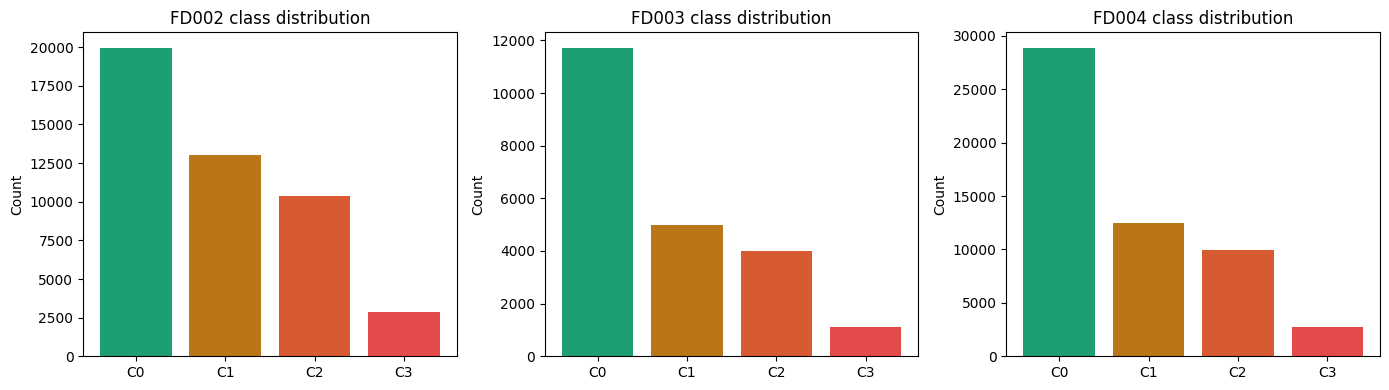

In [5]:
# class distribution comparison across all subsets
fig, axes = plt.subplots(1, len(SUBSETS), figsize=(14, 4))
colors = ["#1D9E75","#BA7517","#D85A30","#E24B4A"]
CLASS_NAMES = ["C0","C1","C2","C3"]

for ax, subset in zip(axes, SUBSETS):
    labels = np.load(BASE_DIR / subset / "labels_train.npy")
    dist   = Counter(labels.tolist())
    counts = [dist.get(c, 0) for c in range(4)]
    ax.bar(CLASS_NAMES, counts, color=colors)
    ax.set_title(f"{subset} class distribution")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("../reports/figures/multi_subset_class_dist.png", dpi=150, bbox_inches="tight")
plt.show()
